# Align & Merge Image Burst

In [1]:
from pathlib import Path

import numpy as np
import rawpy
import scipy.ndimage as nd
import tifffile
from matplotlib import pyplot as plt

from base import ISPStep
from configs.config_loader import config
from datasets.hdrplus_downloader import HDRPlusDatasetDownloader
from pipeline import ISPPipeline
from pipeline_steps.align_and_merge import get_luma_proxy
from utils import find_best_figsize, find_best_layout, get_exif_metadata, plot_images

%matplotlib inline
# Set the default figure format for inline matplotlib plots to JPEG for smaller file sizes and faster rendering
%config InlineBackend.figure_format = 'jpeg'
# Configure matplotlib to save figures with tight bounding boxes (removes extra whitespace)
%config InlineBackend.rc = {'savefig.bbox': 'tight'}

## 1. Downloading data

In [2]:
downloader = HDRPlusDatasetDownloader()
source_path = Path(config.links.zurich_example_path)
folder_path = downloader.download(source_path)

2026-04-03 13:27:53.354 | INFO     | datasets.hdrplus_downloader:download:56 - Destination path wasn't explicitly set. Downloading into `/Users/andreiaksionau/Developer/Computational_Photography/ISPFoundry/data/raw/hdrplus_dataset/0047_20160609_133132_746`
2026-04-03 13:27:53.354 | INFO     | datasets.hdrplus_downloader:download:61 - Folder already exists. Force download was disabled.


In [3]:
dng_paths = [p for p in sorted(folder_path.iterdir()) if p.match("payload_*.dng")]
metadata = get_exif_metadata(dng_paths)

raw_images = []

for idx, p in enumerate(dng_paths):
    with rawpy.imread(str(p)) as raw_obj:
        raw_image = raw_obj.raw_image.astype(np.float32)
        raw_images.append(raw_image)
        metadata[idx]["color_desc"] = raw_obj.color_desc.decode()
        metadata[idx]["raw_pattern"] = raw_obj.raw_pattern

lsc_maps = []
for dp in dng_paths:
    lens_shading_map_path = dp.parent / (dp.stem.replace("payload", "lens_shading_map") + ".tiff")
    lens_shading_map = tifffile.imread(lens_shading_map_path)
    lsc_maps.append(lens_shading_map)

print(f"Number of images: {len(raw_images)}, number of LSC maps: {len(lsc_maps)}")

Number of images: 7, number of LSC maps: 7


## 2. Running all prior ISP steps

In [4]:
isp_pipeline = ISPPipeline(steps=[ISPStep.BLACK_LEVEL_SUBTRACTION, ISPStep.LENS_SHADING_CORRECTION])
config_overrides = {ISPStep.LENS_SHADING_CORRECTION: {"lsc_maps": lsc_maps}}
processed_images = isp_pipeline.run(raw_images, metadata, config_overrides=config_overrides)

2026-04-03 13:27:54.337 | INFO     | pipeline:_discover_steps:33 - --- Discovering Pipeline Step Implementations ----
2026-04-03 13:27:54.338 | INFO     | pipeline:_discover_steps:36 - Loaded: align_and_merge
2026-04-03 13:27:54.339 | INFO     | pipeline:_discover_steps:36 - Loaded: black_level_subtraction
2026-04-03 13:27:54.384 | INFO     | pipeline:_discover_steps:36 - Loaded: lens_shading_correction
2026-04-03 13:27:54.413 | INFO     | pipeline:run:78 - Executing step 1/2 `black_level_subtraction` 
2026-04-03 13:27:54.588 | INFO     | pipeline:run:85 - Step 1/2 `black_level_subtraction` took 0:00:00.175089
2026-04-03 13:27:54.588 | INFO     | pipeline:run:78 - Executing step 2/2 `lens_shading_correction` 
2026-04-03 13:27:54.589 | INFO     | pipeline_steps.lens_shading_correction:apply_lens_shading_correction:127 - All lens shading maps are identical. Reusing the first one.
2026-04-03 13:27:54.692 | INFO     | pipeline:run:85 - Step 2/2 `lens_shading_correction` took 0:00:00.103314

### 2.1. Analyzing the difference between images in the burst

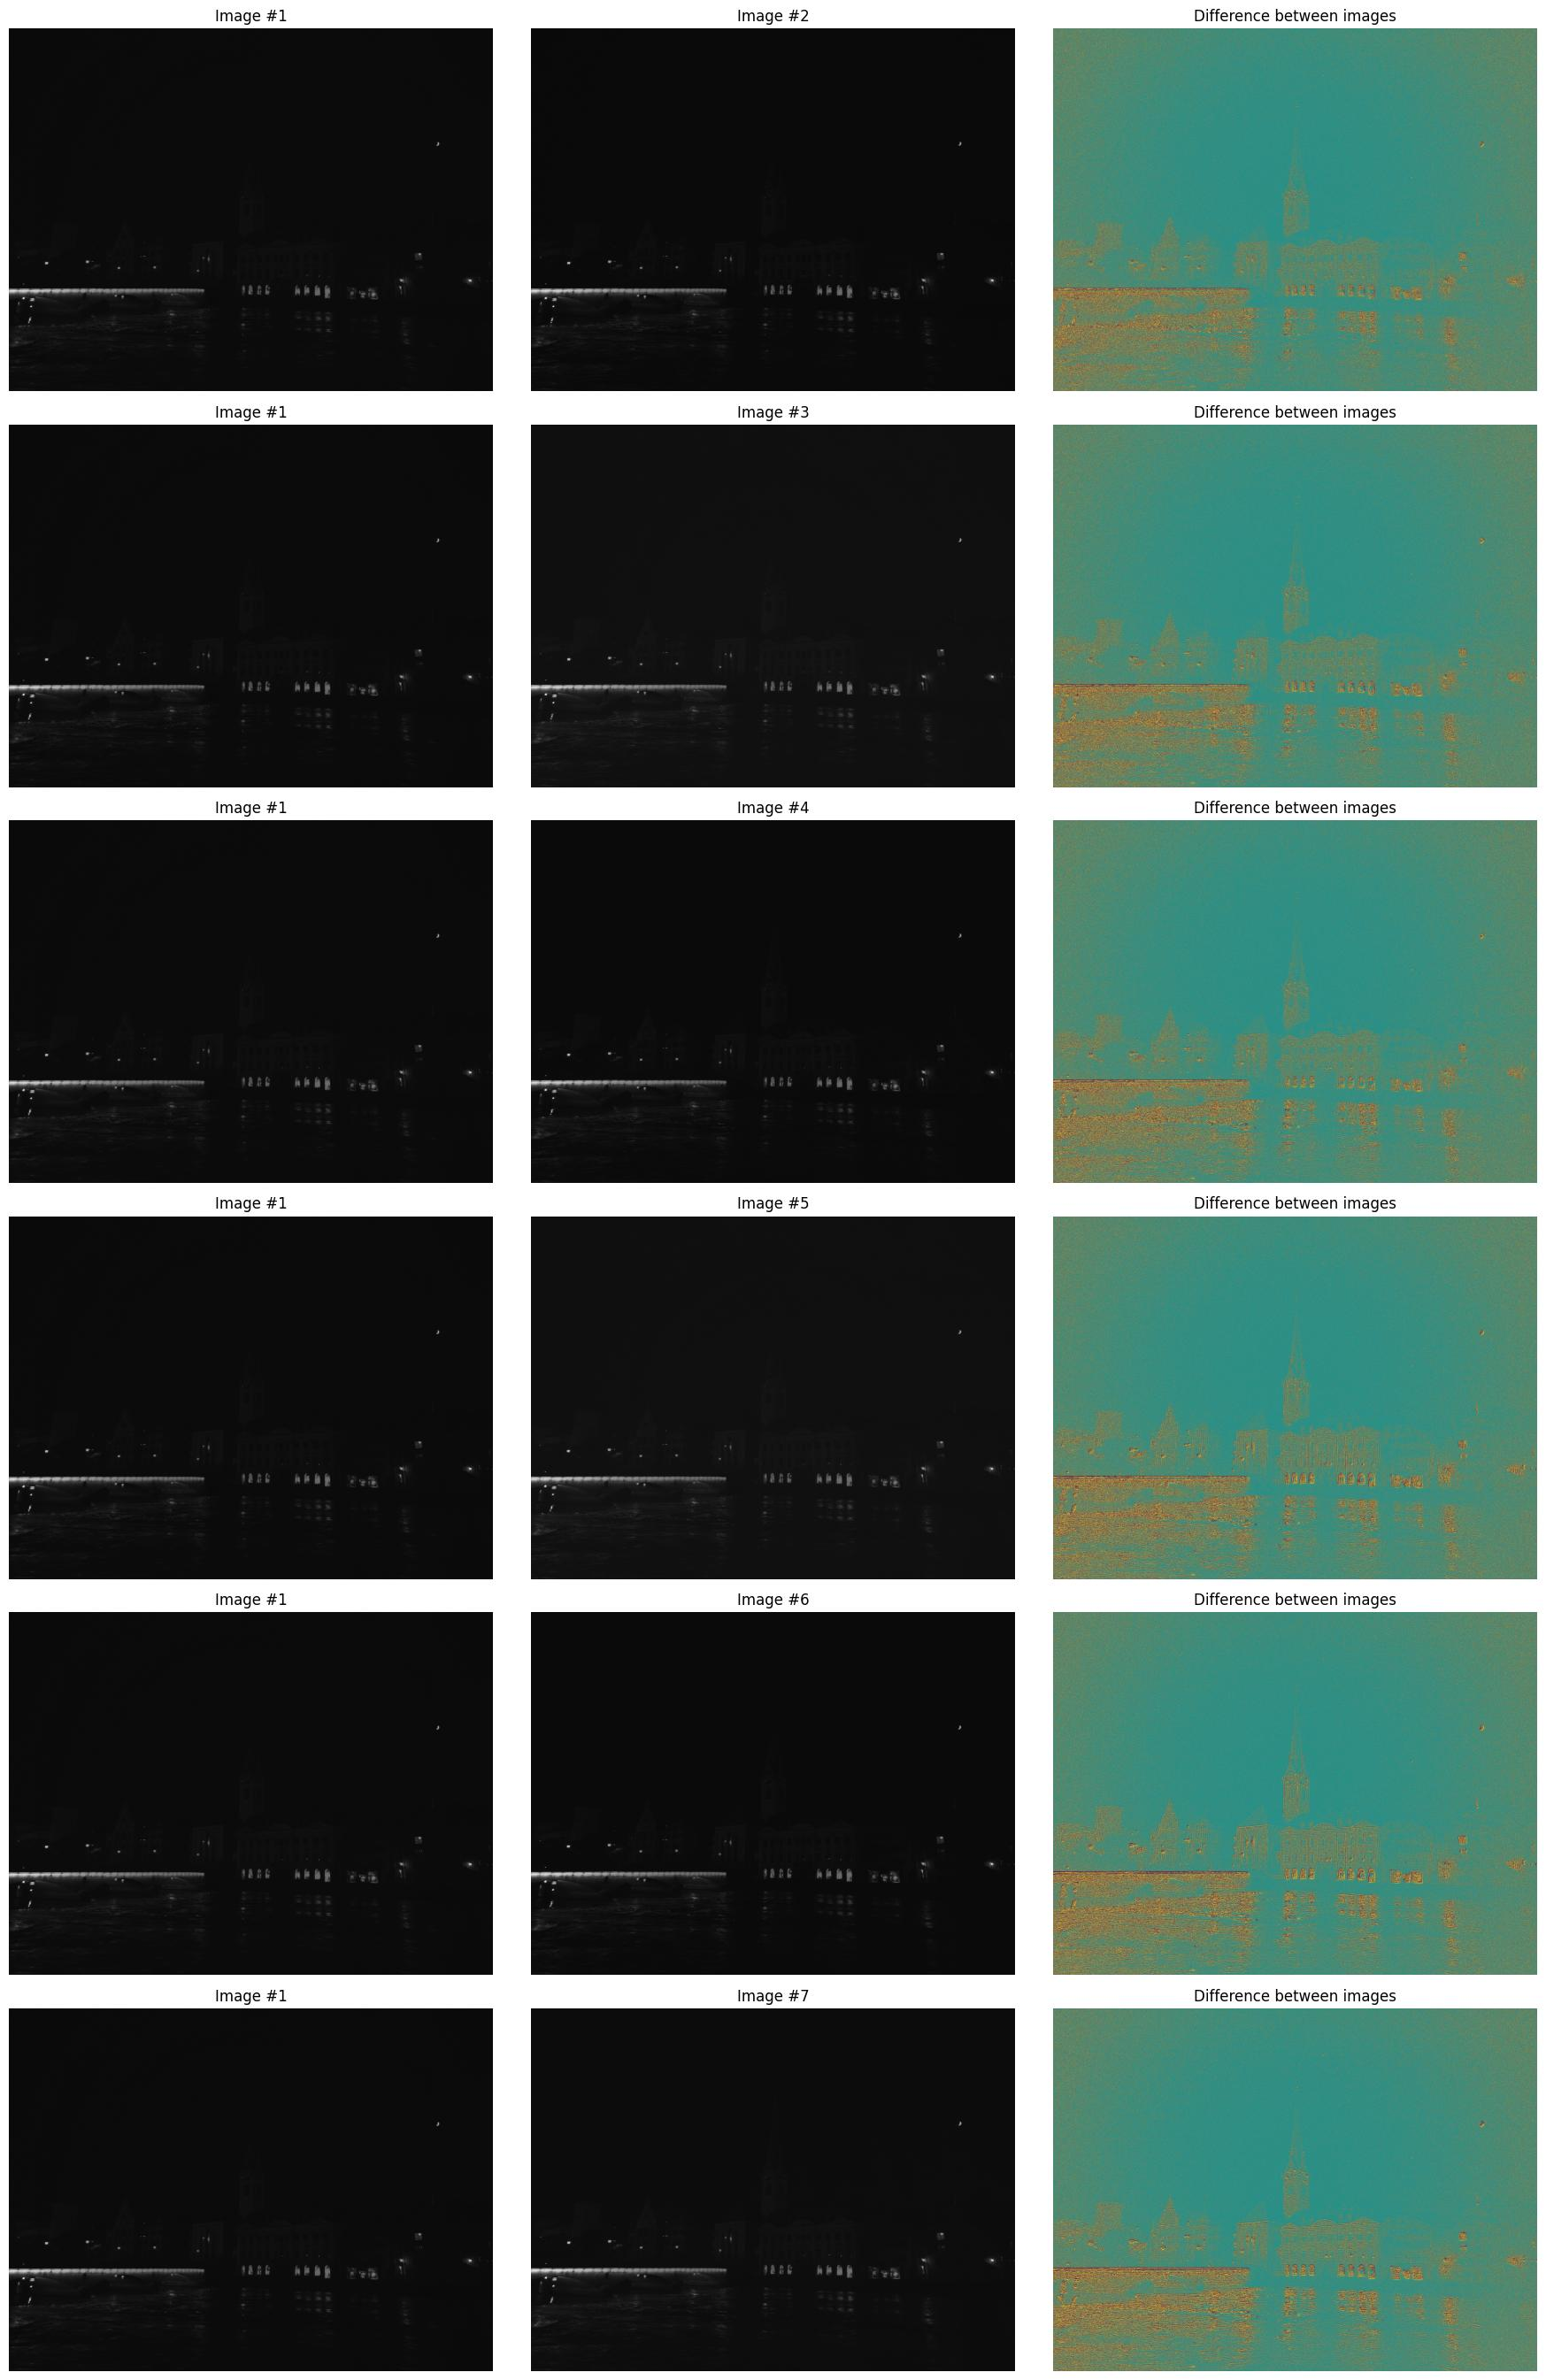

In [5]:
def laplacian_diff(image_1: np.ndarray, image_2: np.ndarray, scale: float = 10.0) -> np.ndarray:
    """
    Visualizes structural alignment errors between two grayscale images by comparing their high-pass (Laplacian) components.

    This method suppresses absolute brightness (DC component) and photon shot noise in highlights, focusing purely on edge displacement.

    Args:
        image_1 (numpy.ndarray): Reference image in range [0, 1].
            Has to be downsampled grayscale (not Bayer).
        image_2 (numpy.ndarray): Alternate image in range [0, 1] to compare.
        scale (float): Multiplier to amplify subtle edge misalignments.
            Defaults to 10.0.

    Returns:
        numpy.ndarray: A grayscale visualization where 0.5 (neutral gray)
            indicates perfect alignment, and bright/dark "double edges"
            indicate spatial shifts.

    """
    # High-pass filter (Laplacian)
    kernel = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0],
    ])
    laplacian_1 = nd.convolve(image_1, kernel)
    laplacian_2 = nd.convolve(image_2, kernel)

    # 0.5 is "neutral gray"
    return np.clip(0.5 + (laplacian_1 - laplacian_2) * scale, 0, 1)


ref_image = processed_images[0]
ref_metadata = metadata[0]
ref_luma = get_luma_proxy(ref_image, ref_metadata)


best_nrow, best_ncol = find_best_layout((len(processed_images) - 1) * 3)
fig_size = find_best_figsize(processed_images, best_nrow, best_ncol)

_, axes = plt.subplots(best_nrow, best_ncol, figsize=fig_size)
# Turn off all axes in one go
for ax in axes.flat:
    ax.axis("off")
axes = axes.flat

for idx in range(1, len(processed_images)):
    ax = next(axes)
    ax.set_title("Image #1")
    ax.imshow(ref_image, cmap="grey")

    ax = next(axes)
    tgt_image = processed_images[idx]
    tgt_metadata = metadata[idx]
    ax.set_title(f"Image #{idx + 1}")
    ax.imshow(tgt_image, cmap="grey")

    ax = next(axes)
    tgt_luma = get_luma_proxy(tgt_image, tgt_metadata)
    ax.set_title("Difference between images")
    ax.imshow(laplacian_diff(ref_luma, tgt_luma))

plt.tight_layout()

## 3. Align & Merge

In [6]:
isp_pipeline.steps = [ISPStep.ALIGN_AND_MERGE]
merged_image = isp_pipeline.run(processed_images, metadata)

2026-04-03 13:28:04.710 | INFO     | pipeline:run:78 - Executing step 1/1 `align_and_merge` 
2026-04-03 13:28:05.009 | INFO     | pipeline_steps.align_and_merge:find_sharpest_image_idx:175 - Lucky Imaging: Selected frame `1` (+5.4% sharper than short-exposure avg)
Align&Merge (Images): 100%|##########| 7/7 [00:02<00:00,  2.52it/s]
2026-04-03 13:28:07.853 | INFO     | pipeline:run:85 - Step 1/1 `align_and_merge` took 0:00:03.142993
2026-04-03 13:28:07.853 | INFO     | pipeline:run:101 - Full run took 0:00:03.143341


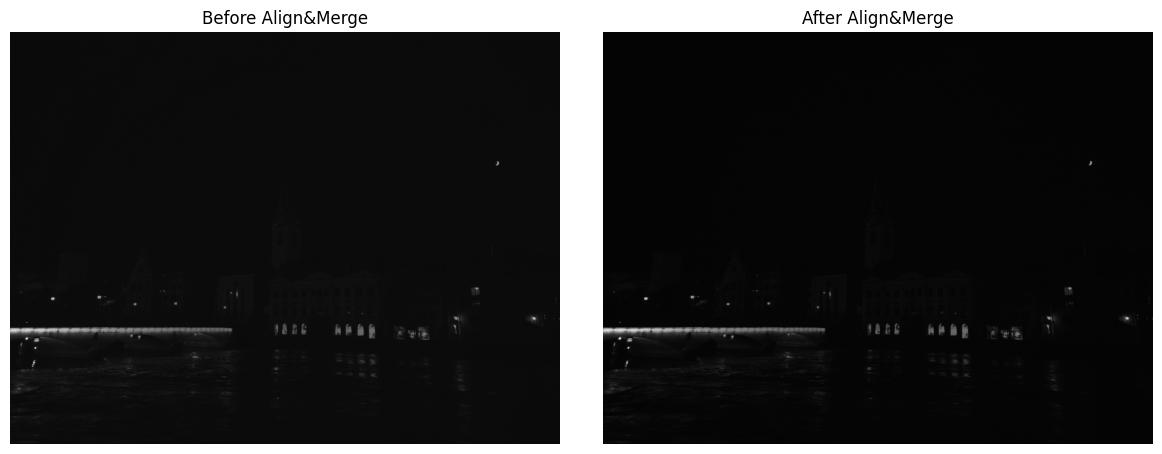

In [7]:
imgs = [processed_images[0], merged_image]
titles = ["Before Align&Merge", "After Align&Merge"]
plot_images(imgs, titles)

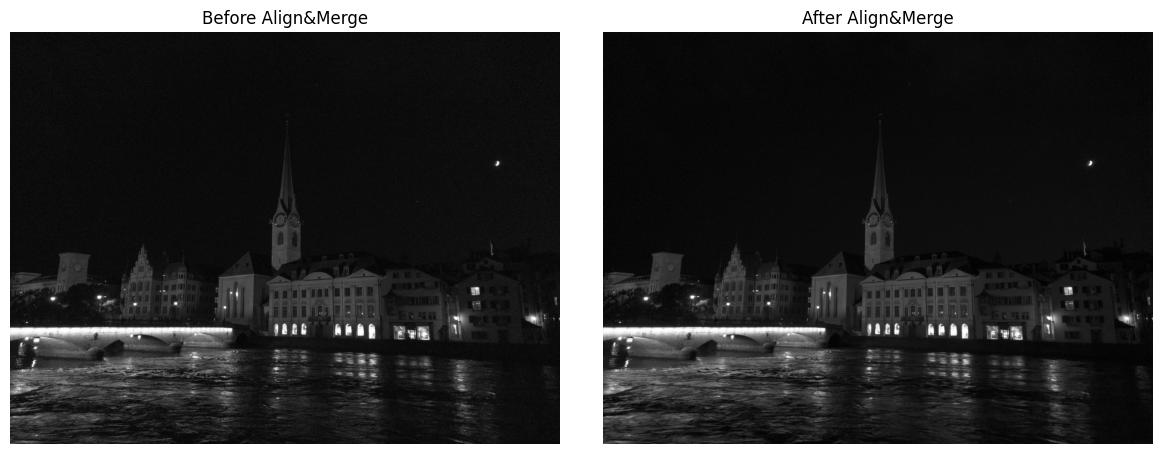

In [8]:
imgs = [processed_images[0], merged_image]
imgs = [x.clip(0, 1) ** (1 / 2.2) for x in imgs]
titles = ["Before Align&Merge", "After Align&Merge"]
plot_images(imgs, titles)

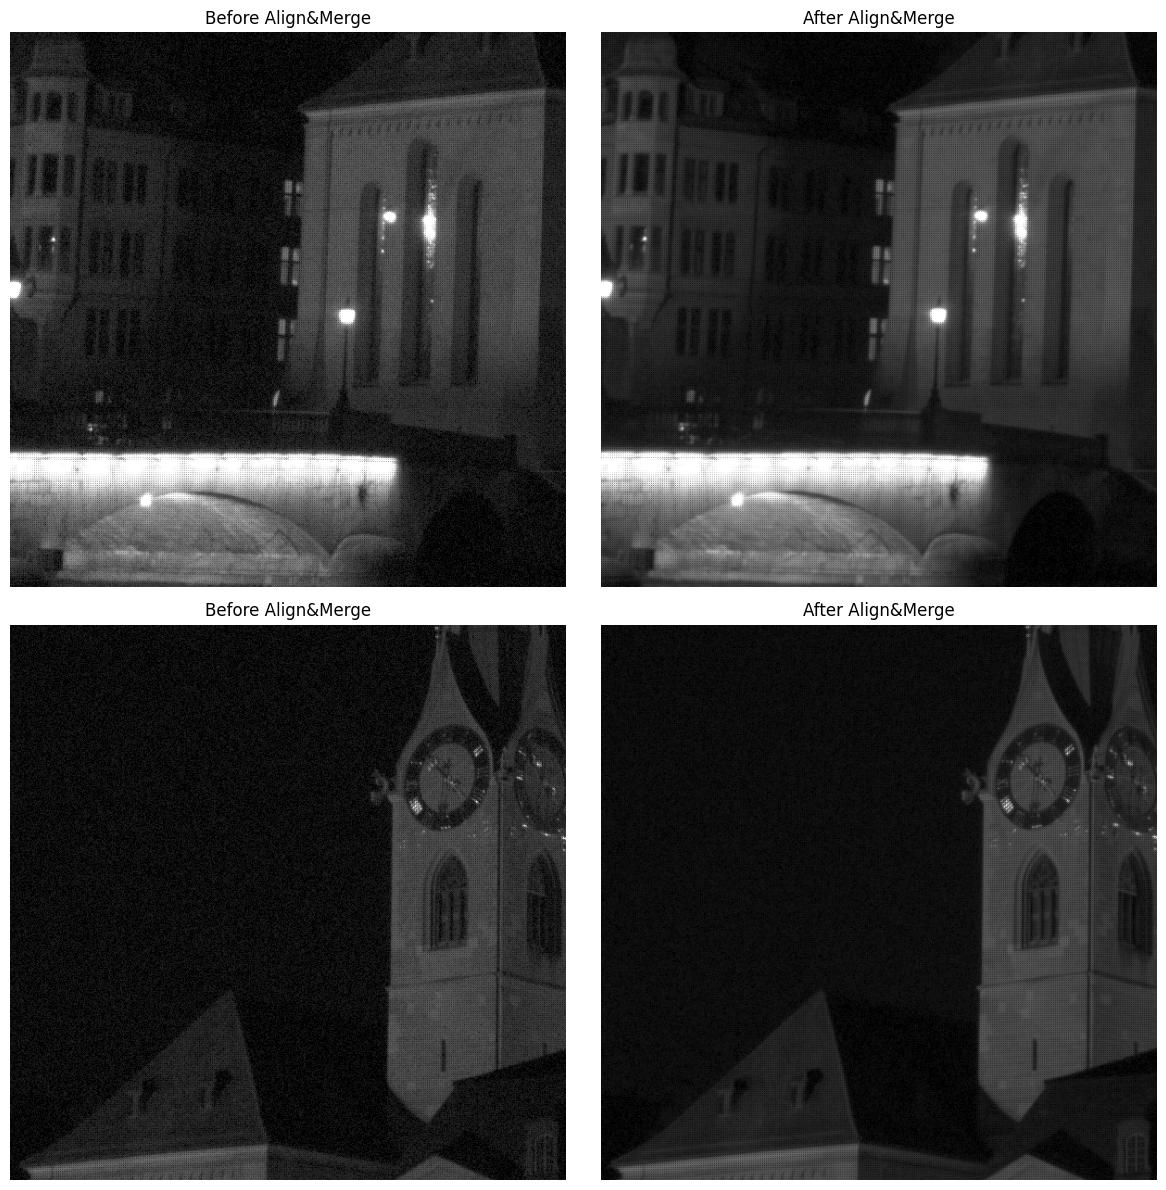

In [9]:
def get_crop(img: np.ndarray, window_size: int = 300, shift_y: int = 0, shift_x: int = 0) -> np.ndarray:  # noqa: D103
    center_x = img.shape[0] // 2
    center_y = img.shape[1] // 2
    return img[
        center_y - window_size + shift_y : center_y + window_size + shift_y,
        center_x - window_size + shift_x : center_x + window_size + shift_x,
    ]


zoomed_in_imgs = [
    get_crop(imgs[0], window_size=300),
    get_crop(imgs[1], window_size=300),
    get_crop(imgs[0], window_size=300, shift_y=-500, shift_x=300),
    get_crop(imgs[1], window_size=300, shift_y=-500, shift_x=300),
]

plot_images(zoomed_in_imgs, titles * 2, max_per_row=2)

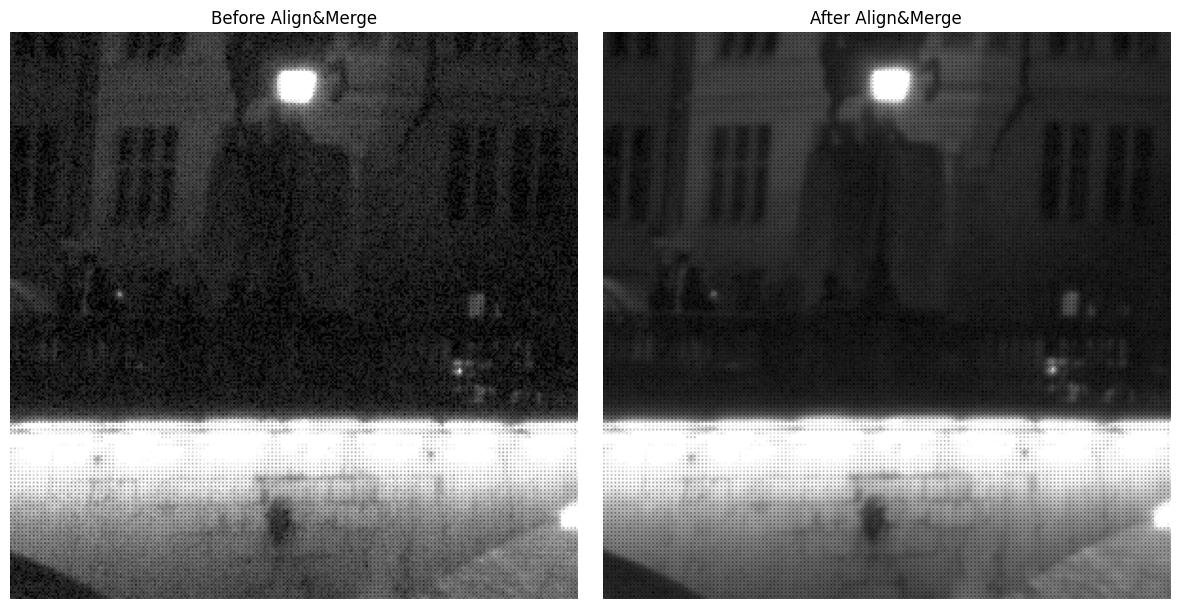

In [10]:
zoomed_in_imgs = [
    get_crop(imgs[0], window_size=150, shift_y=100, shift_x=-300),
    get_crop(imgs[1], window_size=150, shift_y=100, shift_x=-300),
]

plot_images(zoomed_in_imgs, titles, max_per_row=2)

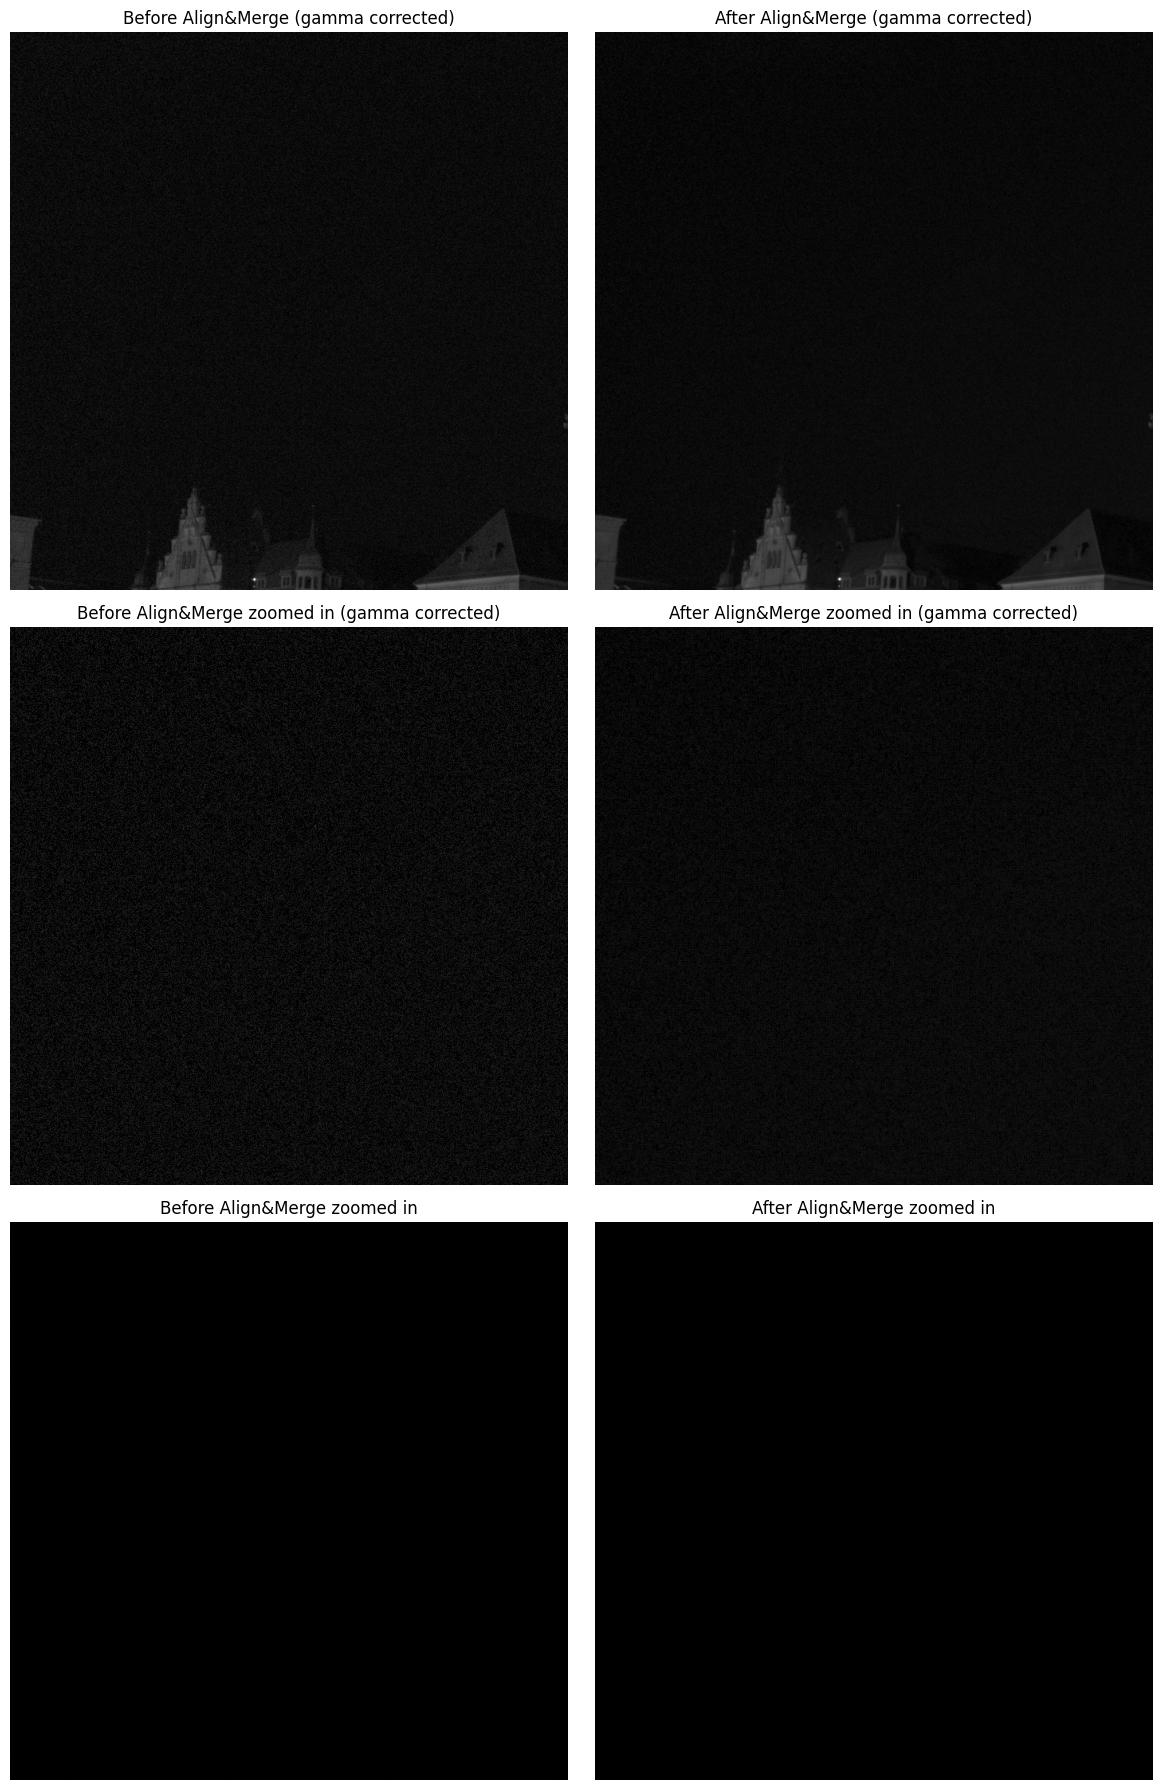

In [20]:
def apply_gamma(x: np.ndarray) -> np.ndarray:  # noqa: D103
    return x.clip(0, 1) ** (1 / 2.2)


imgs = [processed_images[0], merged_image]

zoomed_in_imgs = [
    get_crop(apply_gamma(imgs[0]), window_size=700, shift_y=-900, shift_x=-300),
    get_crop(apply_gamma(imgs[1]), window_size=700, shift_y=-900, shift_x=-300),
    get_crop(apply_gamma(imgs[0]), window_size=350, shift_y=-900, shift_x=-300),
    get_crop(apply_gamma(imgs[1]), window_size=350, shift_y=-900, shift_x=-300),
    get_crop(imgs[0], window_size=350, shift_y=-900, shift_x=-300),
    get_crop(imgs[1], window_size=350, shift_y=-900, shift_x=-300),
]
titles = [
    "Before Align&Merge (gamma corrected)",
    "After Align&Merge (gamma corrected)",
    "Before Align&Merge zoomed in (gamma corrected)",
    "After Align&Merge zoomed in (gamma corrected)",
    "Before Align&Merge zoomed in",
    "After Align&Merge zoomed in",
]

plot_images(zoomed_in_imgs, titles, max_per_row=2)

In [28]:
ref_crop, tgt_crop = zoomed_in_imgs[-2:]
print(f"Size of the patch: reference shape is {ref_crop.shape} | target shape is {tgt_crop.shape}")

ref_snr = ref_crop.mean() / ref_crop.std()
tgt_snr = tgt_crop.mean() / tgt_crop.std()

print(f"Signal-to-Noise ratio of the reference crop: {ref_snr:.4f}")
print(f"Signal-to-Noise ratio of the target crop: {tgt_snr:.4f}")
print(f"After merging SNR increase by a factor of {tgt_snr / ref_snr:.4f}")

Size of the patch: reference shape is (700, 700) | target shape is (700, 700)
Signal-to-Noise ratio of the reference crop: 0.2320
Signal-to-Noise ratio of the target crop: 0.7423
After merging SNR increase by a factor of 3.1994


In [29]:
np.sqrt(len(processed_images))

np.float64(2.6457513110645907)